# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Linear Probability Model

---
## Foreword

In this notebook, my goal is to explore a linear probability model to predict herding events, as denoted by $\textit{rh\_herd}_{i, t} = 1$.


## 1. Libraries & Data

I first load the relevant libraries and data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels import OLS
from linearmodels.panel import PanelOLS

Once I loaded the libraries, I proceed to load the data.

In [2]:
# load attention sample
df = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")

# parse dates
df["date"] = pd.to_datetime(df["date"])

# sort by ticker and date
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

# display first rows
df.head()

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23961/178451985.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")


,date,users_close,users_start,users_last,intraday_userchg,ticker,permno,ret,prc,vol,...,daily_buys,daily_sells,net_buys,taq_retimb,has_users,asvi,valid_rh,users_close_lag1,shortlist_herd,rh_herd
0,2018-05-02,NaN,586.0,586.0,NaN,A,87432.0,-0.004982,65.91,2240482.0,...,122.0,121.0,1.0,0.004115,0,NaN,1,NaN,False,False
1,2018-05-03,587.0,587.0,587.0,0.0,A,87432.0,0.006524,66.34,2365851.0,...,148.0,191.0,-43.0,-0.126844,1,NaN,1,NaN,False,False
2,2018-05-04,NaN,588.0,588.0,NaN,A,87432.0,0.009949,67.00,1331017.0,...,165.0,158.0,7.0,0.021672,0,0.678034,1,587.0,False,False
3,2018-05-07,NaN,584.0,576.0,NaN,A,87432.0,0.005821,67.39,1468735.0,...,161.0,179.0,-18.0,-0.052941,0,0.605674,1,NaN,False,False
4,2018-05-08,580.0,577.0,580.0,3.0,A,87432.0,-0.000297,67.37,1916103.0,...,151.0,162.0,-11.0,-0.035144,1,0.703842,1,NaN,False,False


## 2. Linear Probability Model

In this section, I will run the following linear probability model, where standard errors will be clustered by dates and stocks:

$$
rh\_herd_{i,t} = \alpha_i + \delta_t + \beta\,asvi_{i,t-1} + \lambda X_{i,t-1} + \varepsilon_{i,t}
$$

where $X_{t - 1}$ is a matrix including various control variables at time $t = -1$. I will estimate the linear probability model with `PanelOLS`. The parameter of interest is $\beta$. Furthermore, $\textit{asvi}_{i, t}$ is defined as:

$$
\textit{asvi}_{i, t - 1} = \ln\left( 1 + \frac{\textit{svi}_{i, t - 1}}{\frac{1}{20}\sum_{\tau = 2}^{21} \textit{svi}_{i, t - \tau}}\right)
$$

In my dataset the $asvi$ is already a measure lagged by $1$!

### 2.1. Control Variables

I now build a first control variable to account for extreme returns: $\textit{top\_20}_{i, t - 1}$.

In [3]:
# ret(t - 1)
df['ret_lag1'] = df.groupby('ticker')['ret'].shift(1)

# binary indicator for ret(t - 1) in the top 20 of the absolute returns. 
# if ret(t - 1) is in the top 20 of the absolute returns, then ab_ret_lag1 is 1, otherwise 0.
df['top_20'] = (df['ret_lag1'].abs() >= df.groupby('ticker')['ret'].transform(lambda x: x.abs().nlargest(20).min())).astype(int)

Then, I build a measure of abnormal trading volume to align with the literature.

In [4]:
# ab_vol_lag1 = log(1 + abs(vol(t - 1) / mu)), where mu is the average of vol(t - k) for k = 2, ..., 21.
def make_ab_vol(s):
    lags = pd.concat([s.shift(k) for k in range(2, 22)], axis=1)
    mu = lags.mean(axis=1)
    ratio = s.shift(1) / mu
    ratio[mu == 0] = np.nan
    return np.log1p(np.abs(ratio))

df["ab_vol_lag1"] = df.groupby("ticker")["vol"].transform(make_ab_vol)

I impute news and sentiment data and create a lag.

In [5]:
# replace nan values in num_news, num_news_relevant, ess, css, and anl_chg with 0 (assuming no news and no analyst changes if missing)
df.fillna({'num_news': 0, 'num_news_relevant': 0, 'ess': 0, 'css': 0, 'anl_chg': 0}, inplace=True)

assert df[['num_news', 'num_news_relevant', 'ess', 'css', 'anl_chg']].isnull().sum().sum() == 0, \
"There are still NaN values in the news and analyst change variables."

# create lagged variables by 1
df['num_news_lag1'] = df.groupby('ticker')['num_news'].shift(1)
df['num_news_relevant_lag1'] = df.groupby('ticker')['num_news_relevant'].shift(1)
df['ess_lag1'] = df.groupby('ticker')['ess'].shift(1)
df['css_lag1'] = df.groupby('ticker')['css'].shift(1)
df['anl_chg_lag1'] = df.groupby('ticker')['anl_chg'].shift(1)

Finally, I create a lagged measure of the variable $\textit{userchg}_{i, t}$ and of the dependent variable $\textit{rh\_herd}_{i, t}$

In [6]:
# lagged measure for the variable userchg
df['userchg_lag1'] = df.groupby('ticker')['userchg'].shift(1)

# lagged measure for rh_herd
df['rh_herd_lag1'] = df.groupby('ticker')['rh_herd'].shift(1)

In [7]:
# chek the number of missing values in rh_herd
print(f"Number of missing values in rh_herd: {df['rh_herd'].isnull().sum()}")

Number of missing values in rh_herd: 0


### 2.2. Regressions

I run a first regressions with minimal controls.

In [8]:
# reg data
reg1 = df.copy().dropna(subset=['rh_herd', 'top_20', 'ab_vol_lag1', 'asvi', 'userchg_lag1', 'userchg',
                                'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'rh_herd_lag1'])

# make sure date is datetime
reg1['date'] = pd.to_datetime(reg1['date'])

# set panel index: entity = ticker, time = date
reg1 = reg1.set_index(['ticker', 'date']).sort_index()

# dependent variable (set as int)
y1 = reg1['rh_herd'].astype(int)

# assert that y1 either takes the value 0 or 1
assert set(y1.unique()).issubset({0, 1}), "Dependent variable rh_herd contains values other than 0 and 1."

# regressors: do NOT add a constant when using both entity and time fixed effects
X1 = reg1[[
    'top_20', 'ab_vol_lag1', 'asvi'
]]

# fit the model with entity and time fixed effects
model1 = PanelOLS(y1, X1, entity_effects=True, time_effects=True)
results1_fe = model1.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results1_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23961/2532461569.py:24: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results1_fe = model1.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                rh_herd   R-squared:                        0.0061
Estimator:                   PanelOLS   R-squared (Between):             -1.6855
No. Observations:              934966   R-squared (Within):               0.0049
Date:                Sat, May 02 2026   R-squared (Overall):             -0.0134
Time:                        23:58:01   Log-likelihood                  1.59e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1908.8
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:                F(3,932475)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             131.44
                            

I now control for persistence and expect to see some important changes in both the magnitude and direction of the above estimated coefficients.

In [9]:
# reg data
reg2 = df.copy().dropna(subset=['rh_herd', 'top_20', 'ab_vol_lag1', 'asvi', 'userchg_lag1', 'userchg',
                                'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'rh_herd_lag1'])

# make sure date is datetime
reg2['date'] = pd.to_datetime(reg2['date'])

# set panel index: entity = ticker, time = date
reg2 = reg2.set_index(['ticker', 'date']).sort_index()

# dependent variable (set as int)
y2 = reg2['rh_herd'].astype(int)

# assert that y2 either takes the value 0 or 1
assert set(y2.unique()).issubset({0, 1}), "Dependent variable rh_herd contains values other than 0 and 1."

# regressors: do NOT add a constant when using both entity and time fixed effects
reg2['userchg_lag1'] = reg2['userchg_lag1'] / 1000  # scale userchg_lag1 to thousands
X2 = reg2[[
    'asvi', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'rh_herd_lag1'
]]

# fit the model with entity and time fixed effects
model2 = PanelOLS(y2, X2, entity_effects=True, time_effects=True)
results2_fe = model2.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results2_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23961/2468640928.py:25: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results2_fe = model2.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                rh_herd   R-squared:                        0.0208
Estimator:                   PanelOLS   R-squared (Between):             -0.2983
No. Observations:              934966   R-squared (Within):               0.0204
Date:                Sat, May 02 2026   R-squared (Overall):              0.0161
Time:                        23:58:35   Log-likelihood                 1.597e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3970.1
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:                F(5,932473)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             132.85
                            

We see that persistence exists but do not change the direction or magnitude of the other coefficients.

I further control for news.

In [10]:
# reg data
reg3 = df.copy().dropna(subset=['rh_herd', 'top_20', 'ab_vol_lag1', 'asvi', 'userchg_lag1', 'userchg',
                                'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'rh_herd_lag1'])

# make sure date is datetime
reg3['date'] = pd.to_datetime(reg3['date'])

# set panel index: entity = ticker, time = date
reg3 = reg3.set_index(['ticker', 'date']).sort_index()

# dependent variable (set as int)
y3 = reg3['rh_herd'].astype(int)

# assert that y3 either takes the value 0 or 1
assert set(y3.unique()).issubset({0, 1}), "Dependent variable rh_herd contains values other than 0 and 1."

# regressors: do NOT add a constant when using both entity and time fixed effects
reg3['userchg_lag1'] = reg3['userchg_lag1'] / 1000  # scale userchg_lag1 to thousands
X3 = reg3[[
    'asvi', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'num_news_lag1', 'num_news_relevant_lag1', 'rh_herd_lag1'
]]

# fit the model with entity and time fixed effects
model3 = PanelOLS(y3, X3, entity_effects=True, time_effects=True)
results3_fe = model3.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results3_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23961/3017941763.py:25: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results3_fe = model3.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                rh_herd   R-squared:                        0.0208
Estimator:                   PanelOLS   R-squared (Between):             -0.2982
No. Observations:              934966   R-squared (Within):               0.0204
Date:                Sat, May 02 2026   R-squared (Overall):              0.0161
Time:                        23:59:24   Log-likelihood                 1.597e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2835.8
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:                F(7,932471)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             94.960
                            

And finally for sentiment.

In [11]:
# reg data
reg4 = df.copy().dropna(subset=['rh_herd', 'top_20', 'ab_vol_lag1', 'asvi', 'userchg_lag1', 'userchg',
                                'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'rh_herd_lag1'])

# make sure date is datetime
reg4['date'] = pd.to_datetime(reg4['date'])

# set panel index: entity = ticker, time = date
reg4 = reg4.set_index(['ticker', 'date']).sort_index()

# dependent variable (set as int)
y4 = reg4['rh_herd'].astype(int)

# assert that y4 either takes the value 0 or 1
assert set(y4.unique()).issubset({0, 1}), "Dependent variable rh_herd contains values other than 0 and 1."

# regressors: do NOT add a constant when using both entity and time fixed effects
reg4['userchg_lag1'] = reg4['userchg_lag1'] / 1000  # scale userchg_lag1 to thousands
reg4['num_news_lag1'] = reg4['num_news_lag1'] / 1000  # scale num_news_lag1 to thousands
reg4['num_news_relevant_lag1'] = reg4['num_news_relevant_lag1'] / 1000  # scale num_news_relevant_lag1 to thousands
X4 = reg4[[
    'asvi', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'rh_herd_lag1'
]]

# fit the model with entity and time fixed effects
model4 = PanelOLS(y4, X4, entity_effects=True, time_effects=True)
results4_fe = model4.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results4_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_23961/3015026060.py:27: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results4_fe = model4.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                rh_herd   R-squared:                        0.0208
Estimator:                   PanelOLS   R-squared (Between):             -0.3052
No. Observations:              934966   R-squared (Within):               0.0204
Date:                Sun, May 03 2026   R-squared (Overall):              0.0161
Time:                        00:00:14   Log-likelihood                 1.597e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1985.4
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:               F(10,932468)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             68.478
                            

We can therefore reasonably conclude that in the LPM, our coefficient of interest, $\beta$ is positive and statistically significant. 

#### 2.2.1. Herding Events and asvi

In [14]:
regherd = df.copy().dropna(subset=['rh_herd', 'top_20', 'ab_vol_lag1', 'asvi', 'userchg_lag1', 'userchg',
                                'num_news', 'num_news_relevant', 'ess', 'css', 'anl_chg'])

# datetime
regherd['date'] = pd.to_datetime(regherd['date'])

# sort by ticker and date
regherd = regherd.sort_values(['ticker', 'date']).reset_index(drop=True)
regherd = regherd.set_index(['ticker', 'date']).sort_index()

# asvi present
regherd['asvi_present'] = regherd.groupby('ticker')['asvi'].shift(-1)

# binary rh_herd
regherd['rh_herd_int'] = regherd['rh_herd'].astype(int)
regherd['rh_herd_int_l1'] = regherd.groupby('ticker')['rh_herd_int'].shift(1)

# interaction term
regherd['asvi_rh_herd'] = regherd['asvi_present'] * regherd['rh_herd_int']

# X
Xherd = regherd[[
    'asvi_present', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'num_news', 'num_news_relevant', 'ess', 'css', 'anl_chg', 'rh_herd_int', 'asvi_rh_herd'
]]

yherd = regherd['userchg']

# fit the model with entity and time fixed effects
model_herd = PanelOLS(yherd, Xherd, entity_effects=True, time_effects=True)
results_herd = model_herd.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
print(results_herd.summary)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_38420/2247091534.py:30: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results_herd = model_herd.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.3778
Estimator:                   PanelOLS   R-squared (Between):              0.8331
No. Observations:              933008   R-squared (Within):               0.3813
Date:                Mon, Apr 13 2026   R-squared (Overall):              0.4148
Time:                        13:28:34   Log-likelihood                -6.519e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   5.135e+04
Entities:                        1956   P-value                           0.0000
Avg Obs:                       477.00   Distribution:               F(11,930512)
Min Obs:                       1.0000                                           
Max Obs:                       530.00   F-statistic (robust):             39.042
                            

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_38420/1325269545.py:41: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  y_res = y_model.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_38420/1325269545.py:53: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates d

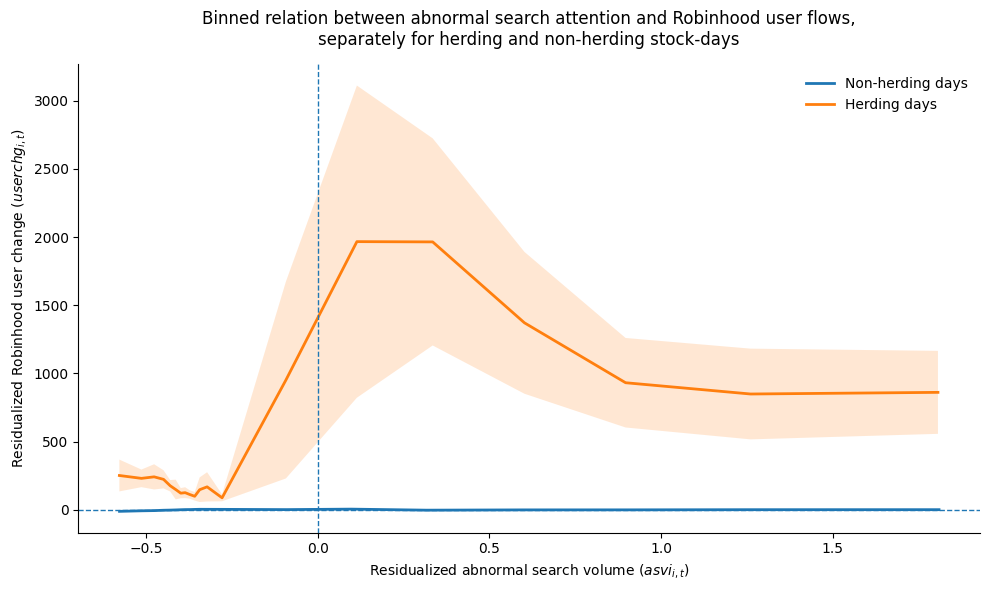

In [16]:
# ============================================================
# INTERACTION DESIGN: PREPARE DATA
# ============================================================

# ----------------------------
# 1. Build estimation sample
# ----------------------------
regint = df.copy().dropna(subset=[
    'userchg', 'asvi', 'rh_herd', 'top_20', 'ab_vol_lag1',
    'userchg_lag1', 'num_news', 'num_news_relevant', 'ess', 'css', 'anl_chg'
])
regint['asvi_present'] = regint.groupby('ticker')['asvi'].shift(-1)

regint['date'] = pd.to_datetime(regint['date'])
regint = regint.sort_values(['ticker', 'date']).reset_index(drop=True)

# binary herd indicator
regint['rh_herd_int'] = regint['rh_herd'].astype(int)

# set panel index
regint = regint.set_index(['ticker', 'date']).sort_index()

# ----------------------------
# 2. Controls to partial out
#    (exclude asvi, herd, interaction)
# ----------------------------
controls = [
    'top_20', 'ab_vol_lag1', 'userchg_lag1',
    'num_news', 'num_news_relevant', 'ess', 'css', 'anl_chg'
]

# ----------------------------
# 3. Partial out controls + FE from userchg
# ----------------------------
y_model = PanelOLS(
    regint['userchg'],
    regint[controls],
    entity_effects=True,
    time_effects=True
)
y_res = y_model.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
regint['userchg_resid'] = y_res.resids

# ----------------------------
# 4. Partial out controls + FE from asvi
# ----------------------------
x_model = PanelOLS(
    regint['asvi_present'],
    regint[controls],
    entity_effects=True,
    time_effects=True
)
x_res = x_model.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
regint['asvi_resid'] = x_res.resids

# reset index for plotting
plot_df = regint.reset_index().copy()

# ============================================================
# BINNED DOSE-RESPONSE PLOT
# ============================================================

# Keep finite values only
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=['userchg_resid', 'asvi_resid', 'rh_herd_int'])

# Optional: trim extreme tails of residual ASVI for readability
low_q = plot_df['asvi_resid'].quantile(0.01)
high_q = plot_df['asvi_resid'].quantile(0.99)
plot_df = plot_df.loc[(plot_df['asvi_resid'] >= low_q) & (plot_df['asvi_resid'] <= high_q)].copy()

# Create quantile bins on residualized ASVI
n_bins = 20
plot_df['asvi_bin'] = pd.qcut(plot_df['asvi_resid'], q=n_bins, duplicates='drop')

# Compute grouped means and 90% CI
binned = (
    plot_df
    .groupby(['rh_herd_int', 'asvi_bin'], observed=True)
    .agg(
        mean_x=('asvi_resid', 'mean'),
        mean_y=('userchg_resid', 'mean'),
        sd_y=('userchg_resid', 'std'),
        n=('userchg_resid', 'size')
    )
    .reset_index()
)

# 90% CI using normal approximation
z90 = 1.645
binned['se_y'] = binned['sd_y'] / np.sqrt(binned['n'])
binned['ci_low'] = binned['mean_y'] - z90 * binned['se_y']
binned['ci_high'] = binned['mean_y'] + z90 * binned['se_y']

# Split by herd status
b0 = binned[binned['rh_herd_int'] == 0].sort_values('mean_x')
b1 = binned[binned['rh_herd_int'] == 1].sort_values('mean_x')

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

# herd = 0
ax.plot(
    b0['mean_x'], b0['mean_y'],
    linewidth=2.0,
    label='Non-herding days'
)
ax.fill_between(
    b0['mean_x'], b0['ci_low'], b0['ci_high'],
    alpha=0.18
)

# herd = 1
ax.plot(
    b1['mean_x'], b1['mean_y'],
    linewidth=2.0,
    label='Herding days'
)
ax.fill_between(
    b1['mean_x'], b1['ci_low'], b1['ci_high'],
    alpha=0.18
)

ax.axhline(0, linewidth=1.0, linestyle='--')
ax.axvline(0, linewidth=1.0, linestyle='--')

ax.set_xlabel('Residualized abnormal search volume ($asvi_{i,t}$)')
ax.set_ylabel('Residualized Robinhood user change ($userchg_{i,t}$)')
ax.set_title(
    'Binned relation between abnormal search attention and Robinhood user flows,\n'
    'separately for herding and non-herding stock-days',
    fontsize=12,
    pad=14
)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig("../assets/figures/Interaction_ASVI_Herding_Binscatter.pdf", bbox_inches='tight')
plt.show()

### 2.3. Small Caps Amplification?

Now, I want to test whether small cap amplify the phenomenon above. I therefore build different binary indicators to account for this phenomenon.

In [12]:
# market cap in million at the open
df['shrout_lag1'] = df.groupby('ticker')['shrout'].shift(1)

# mktcap (at the open)
df['mktcap'] = df['shrout_lag1'] * df['open_price'] / 1e3 # mktcap is expressed in $mil.

# mktcap_under10 = 1 if mktcap < 10th percentile of mktcap, otherwise 0
mktcap10qt = df['mktcap'].quantile(0.1)
df['mktcap_under10'] = (df['mktcap'] < mktcap10qt).astype(int)

# mktcap_under25 = 1 if mktcap < 25th percentile of mktcap, otherwise 0
mktcap25qt = df['mktcap'].quantile(0.25)
df['mktcap_under25'] = (df['mktcap'] < mktcap25qt).astype(int)

Now, I will run the following regressions:

$$
rh\_herd_{i,t} = \alpha_i + \delta_t + \beta_1\,asvi_{i,t-1} + \beta_2 asvi_{i,t-1} \cdot \textit{mktcap\_under}(k)_{i, t} + \lambda X_{i,t-1} + u_{i,t}
$$

I do not include a stand-alone dummy for $\textit{mktcap\_under}(k)_{i, t}$ because it will be perfectly collinear with entity fixed effects and `PanelOLS` will drop it.

In [34]:
reg5 = df.copy().dropna(subset=['rh_herd', 'top_20', 'ab_vol_lag1', 'asvi', 'userchg_lag1', 'userchg',
                                'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'mktcap_under10', 'rh_herd_lag1'])

# make sure date is datetime
reg5['date'] = pd.to_datetime(reg5['date'])

# set panel index: entity = ticker, time = date
reg5 = reg5.set_index(['ticker', 'date']).sort_index()

# dependent variable (set as int)
y5 = reg5['rh_herd'].astype(int)

# assert that y5 either takes the value 0 or 1
assert set(y5.unique()).issubset({0, 1}), "Dependent variable rh_herd contains values other than 0 and 1."

# create interaction term between mktcap_under10 and asvi
reg5['asvi_mktcap_under10'] = reg5['asvi'] * reg5['mktcap_under10']

# regressors: do NOT add a constant when using both entity and time fixed effects
X5 = reg5[[
    'asvi', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'num_news_lag1', 'num_news_relevant_lag1',
    'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'asvi_mktcap_under10', 'rh_herd_lag1'
]]

# fit the model with entity and time fixed effects
model5 = PanelOLS(y5, X5, entity_effects=True, time_effects=True)
results5_fe = model5.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results5_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_85126/1500675749.py:27: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results5_fe = model5.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                rh_herd   R-squared:                        0.0208
Estimator:                   PanelOLS   R-squared (Between):             -0.3055
No. Observations:              934966   R-squared (Within):               0.0204
Date:                Fri, Apr 03 2026   R-squared (Overall):              0.0161
Time:                        18:59:07   Log-likelihood                 1.597e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1804.9
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:               F(11,932467)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             62.320
                            

Nothing interesting here.

In [35]:
reg6 = df.copy().dropna(subset=['rh_herd', 'top_20', 'ab_vol_lag1', 'asvi', 'userchg_lag1', 'userchg',
                                'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'mktcap_under25', 'rh_herd_lag1'])

# make sure date is datetime
reg6['date'] = pd.to_datetime(reg6['date'])

# set panel index: entity = ticker, time = date
reg6 = reg6.set_index(['ticker', 'date']).sort_index()

# dependent variable (set as int)
y6 = reg6['rh_herd'].astype(int)

# assert that y6 either takes the value 0 or 1
assert set(y6.unique()).issubset({0, 1}), "Dependent variable rh_herd contains values other than 0 and 1."

# create interaction term between mktcap_under25 and asvi
reg6['asvi_mktcap_under25'] = reg6['asvi'] * reg6['mktcap_under25']

# regressors: do NOT add a constant when using both entity and time fixed effects
X6 = reg6[[
    'asvi', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'num_news_lag1', 'num_news_relevant_lag1',
    'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'asvi_mktcap_under25', 'rh_herd_lag1'
]]

# fit the model with entity and time fixed effects
model6 = PanelOLS(y6, X6, entity_effects=True, time_effects=True)
results6_fe = model6.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results6_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_85126/1848463017.py:27: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results6_fe = model6.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                rh_herd   R-squared:                        0.0209
Estimator:                   PanelOLS   R-squared (Between):             -0.2959
No. Observations:              934966   R-squared (Within):               0.0204
Date:                Fri, Apr 03 2026   R-squared (Overall):              0.0162
Time:                        18:59:43   Log-likelihood                 1.597e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1806.4
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:               F(11,932467)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             62.951
                            

In [17]:
print(mktcap10qt)
print(mktcap25qt)

231.28560000000002
675.840375


To have a better picture in mind, I run a broader experiment.

In [36]:
# percentiles from 10th to 90th
percentiles = np.arange(10, 91, 1)

results_list = []

base_cols = [
    'ticker', 'date', 'mktcap', 'rh_herd', 'top_20', 'ab_vol_lag1', 'asvi',
    'userchg_lag1', 'num_news_lag1', 'num_news_relevant_lag1',
    'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'userchg', 'rh_herd_lag1'
]

for p in percentiles:
    q = df['mktcap'].quantile(p / 100)

    reg = df[base_cols].copy()
    reg = reg.dropna().copy()
    reg['date'] = pd.to_datetime(reg['date'])

    # binary indicator: 1 if mktcap is below or equal to the p-th percentile cutoff
    reg[f'mktcap_under{p}'] = (reg['mktcap'] <= q).astype(int)

    # interaction term
    reg[f'asvi_mktcap_under{p}'] = reg['asvi'] * reg[f'mktcap_under{p}']

    # set panel index
    reg = reg.set_index(['ticker', 'date']).sort_index()

    # dependent variable
    y = reg['rh_herd'].astype(int)

    # regressors
    X = reg[[
        'asvi',
        'top_20',
        'ab_vol_lag1',
        'userchg_lag1',
        'num_news_lag1',
        'num_news_relevant_lag1',
        'ess_lag1',
        'css_lag1',
        'anl_chg_lag1',
        'rh_herd_lag1',
        f'asvi_mktcap_under{p}'
    ]]

    # estimate model
    model = PanelOLS(y, X, entity_effects=True, time_effects=True)
    res = model.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

    # marginal effect of ASVI when the indicator = 1
    b_asvi = res.params['asvi']
    b_int = res.params[f'asvi_mktcap_under{p}']
    me = b_asvi + b_int

    # delta-method standard error
    vcov = res.cov
    var_me = (
        vcov.loc['asvi', 'asvi']
        + vcov.loc[f'asvi_mktcap_under{p}', f'asvi_mktcap_under{p}']
        + 2 * vcov.loc['asvi', f'asvi_mktcap_under{p}']
    )
    se_me = np.sqrt(var_me)

    # 90% confidence interval
    z_90 = 1.645
    ci_low = me - z_90 * se_me
    ci_high = me + z_90 * se_me

    results_list.append({
        'percentile': p,
        'threshold_mktcap': q,
        'nobs': res.nobs,
        'beta_asvi': b_asvi,
        'beta_interaction': b_int,
        'marginal_effect': me,
        'se_marginal_effect': se_me,
        'ci90_low': ci_low,
        'ci90_high': ci_high
    })

marginal_effects_df = pd.DataFrame(results_list)
print(marginal_effects_df.head())

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_85126/1099072400.py:48: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  res = model.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_85126/1099072400.py:48: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  res = model.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_85126/1099072400.py:48: MemoryWarning: Using low-memory algorithm

   percentile  threshold_mktcap    nobs  beta_asvi  beta_interaction  \
0          10        231.285600  934591   0.000253         -0.000048   
1          11        255.123642  934591   0.000249         -0.000010   
2          12        277.404399  934591   0.000261         -0.000100   
3          13        302.374775  934591   0.000250         -0.000018   
4          14        326.401484  934591   0.000237          0.000072   

   marginal_effect  se_marginal_effect  ci90_low  ci90_high  
0         0.000205            0.000227 -0.000169   0.000579  
1         0.000239            0.000211 -0.000108   0.000586  
2         0.000161            0.000202 -0.000172   0.000493  
3         0.000233            0.000205 -0.000104   0.000569  
4         0.000309            0.000201 -0.000021   0.000639  


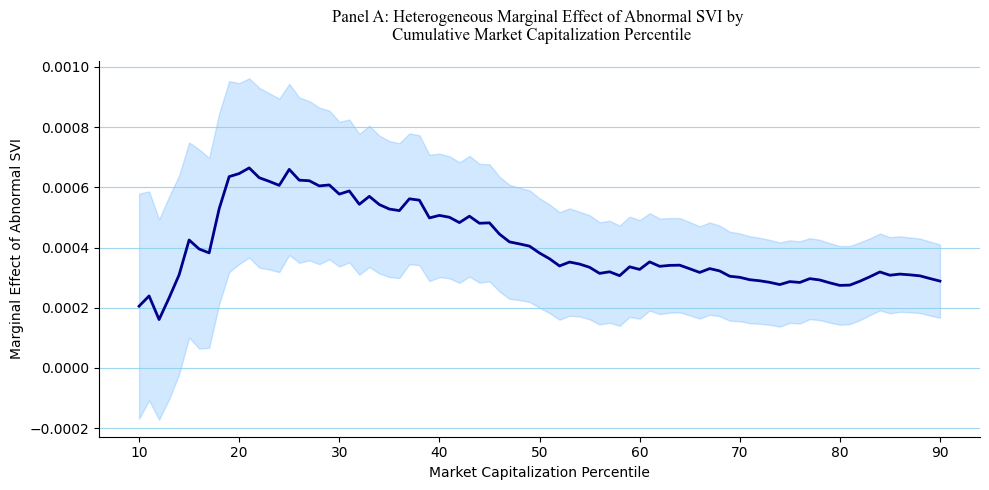

In [37]:
plot_df = marginal_effects_df.sort_values('percentile')

fig, ax = plt.subplots(figsize=(10, 5))

# confidence band
ax.fill_between(
    plot_df['percentile'],
    plot_df['ci90_low'],
    plot_df['ci90_high'],
    alpha=0.2,
    color="dodgerblue"
)

# main line
ax.plot(
    plot_df['percentile'],
    plot_df['marginal_effect'],
    linewidth=2.0,
    color="darkblue"
)

# formatting
ax.set_xlabel('Market Capitalization Percentile')
ax.set_ylabel('Marginal Effect of Abnormal SVI')
ax.set_title("Panel A: Heterogeneous Marginal Effect of Abnormal SVI by \n Cumulative Market Capitalization Percentile",
             fontsize=12, pad=15, family="Times New Roman")
ax.set_xticks(np.arange(10, 91, 10))
ax.grid(axis='y', alpha=0.8, color="skyblue")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../../../figures/marginal_effect_asvi_by_mktcap_percentile.pdf", bbox_inches='tight')
plt.show()

The predictive effect of abnormal search attention on Robinhood herding is strongest among relatively small-cap stocks, with the effect peaking when the small-cap group is defined around the lower quartile of the market-cap distribution. As the threshold expands to include progressively larger firms, the estimated marginal effect declines, suggesting that attention-induced herding is concentrated in the lower tail of the size distribution and becomes diluted when broader groups are considered.

#### Non-overlapping Bins

I now construct market-cap bins using percentiles of the full market-cap distribution, for example deciles or ventiles. Then I estimate one regression with $asvi$ interacted with bin indicators, omitting one bin as the reference category. With stock and date fixed effects, the standalone time-invariant bin dummies are absorbed, but the interaction terms remain identified because $asvi$ varies over time.

The regression is:

$$
rh\_herd_{i,t}
=
\alpha_i + \delta_t
+ \beta\,asvi_{i,t-1}
+ \sum_{g \neq g_0}\gamma_g \big(asvi_{i,t-1}\times 1\{i \in g\}\big)
+ \lambda' X_{i,t-1}
+ \varepsilon_{i,t},
$$

where $g$ indexes non-overlapping size bins and $g_0$ is the omitted reference bin.

Interpretation:
+ $\beta$ is the $asvi$ effect in the omitted reference bin.
+ $\beta + \gamma_g$ is the $asvi$ effect in bin $g$.

This is preferable because it estimates heterogeneous slopes across mutually exclusive size groups. It avoids the nesting problem in my above plot.

In [38]:
# ------------------------------------------------------------
# 1. BUILD ESTIMATION SAMPLE
# ------------------------------------------------------------
reg_bins = df.copy().dropna(subset=[
    'ticker', 'date', 'mktcap', 'rh_herd', 'asvi', 'top_20', 'ab_vol_lag1',
    'userchg_lag1', 'num_news_lag1', 'num_news_relevant_lag1',
    'ess_lag1', 'css_lag1', 'anl_chg_lag1', 'userchg'
]).copy()

reg_bins['date'] = pd.to_datetime(reg_bins['date'])

# dependent variable must be binary
assert set(reg_bins['rh_herd'].astype(int).unique()).issubset({0, 1}), \
    "Dependent variable rh_herd contains values other than 0 and 1."

# ------------------------------------------------------------
# 2. CREATE NON-OVERLAPPING MARKET-CAP BINS
# ------------------------------------------------------------
# Deciles: 10 mutually exclusive groups
# labels 1,...,10 where 1 = smallest-cap decile, 10 = largest-cap decile
reg_bins['mktcap_decile'] = pd.qcut(
    reg_bins['mktcap'],
    q=10,
    labels=False,
    duplicates='drop'
) + 1

# Optional: inspect counts
print(reg_bins['mktcap_decile'].value_counts().sort_index())

# ------------------------------------------------------------
# 3. CREATE ASVI x BIN INTERACTIONS
# ------------------------------------------------------------
# Choose omitted/reference group.
# A natural choice is the largest-cap decile (10), so effects are relative to big stocks.
reference_bin = 10

interaction_cols = []
for d in sorted(reg_bins['mktcap_decile'].unique()):
    if d == reference_bin:
        continue
    col = f'asvi_x_decile{d}'
    reg_bins[col] = reg_bins['asvi'] * (reg_bins['mktcap_decile'] == d).astype(int)
    interaction_cols.append(col)

# ------------------------------------------------------------
# 4. SET PANEL INDEX
# ------------------------------------------------------------
reg_bins = reg_bins.set_index(['ticker', 'date']).sort_index()

y = reg_bins['rh_herd'].astype(int)

base_controls = [
    'asvi',
    'top_20',
    'ab_vol_lag1',
    'userchg_lag1',
    'num_news_lag1',
    'num_news_relevant_lag1',
    'ess_lag1',
    'css_lag1',
    'anl_chg_lag1'
]

X = reg_bins[base_controls + interaction_cols]

# ------------------------------------------------------------
# 5. ESTIMATE MODEL WITH STOCK AND DATE FIXED EFFECTS
# ------------------------------------------------------------
model_bins = PanelOLS(y, X, entity_effects=True, time_effects=True)
results_bins = model_bins.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results_bins.summary)

# ------------------------------------------------------------
# 6. RECOVER BIN-SPECIFIC MARGINAL EFFECTS OF ASVI
# ------------------------------------------------------------
# Effect in reference bin = beta_asvi
# Effect in bin d != ref = beta_asvi + beta_interaction_d

vcov = results_bins.cov
beta_asvi = results_bins.params['asvi']

z_90 = 1.645
rows = []

all_bins = sorted(reg_bins['mktcap_decile'].unique())

for d in all_bins:
    if d == reference_bin:
        me = beta_asvi
        var_me = vcov.loc['asvi', 'asvi']
    else:
        int_col = f'asvi_x_decile{d}'
        me = beta_asvi + results_bins.params[int_col]
        var_me = (
            vcov.loc['asvi', 'asvi']
            + vcov.loc[int_col, int_col]
            + 2 * vcov.loc['asvi', int_col]
        )

    se_me = np.sqrt(var_me)
    ci_low = me - z_90 * se_me
    ci_high = me + z_90 * se_me

    # useful descriptive info
    subset = reg_bins[reg_bins['mktcap_decile'] == d]
    p_low = (d - 1) * 10
    p_high = d * 10

    rows.append({
        'decile': d,
        'percentile_range': f'{p_low}-{p_high}',
        'nobs': subset.shape[0],
        'mktcap_median_bin': subset['mktcap'].median(),
        'marginal_effect': me,
        'se': se_me,
        'ci90_low': ci_low,
        'ci90_high': ci_high
    })

me_deciles = pd.DataFrame(rows).sort_values('decile').reset_index(drop=True)
print(me_deciles)

mktcap_decile
1     93460
2     93459
3     93459
4     93460
5     93458
6     93459
7     93459
8     93459
9     93459
10    93459
Name: count, dtype: int64


/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_85126/3122182292.py:71: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results_bins = model_bins.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                rh_herd   R-squared:                        0.0066
Estimator:                   PanelOLS   R-squared (Between):             -1.6066
No. Observations:              934591   R-squared (Within):               0.0054
Date:                Fri, Apr 03 2026   R-squared (Overall):             -0.0121
Time:                        19:18:01   Log-likelihood                 1.589e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      341.45
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.32   Distribution:               F(18,932085)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             23.638
                            

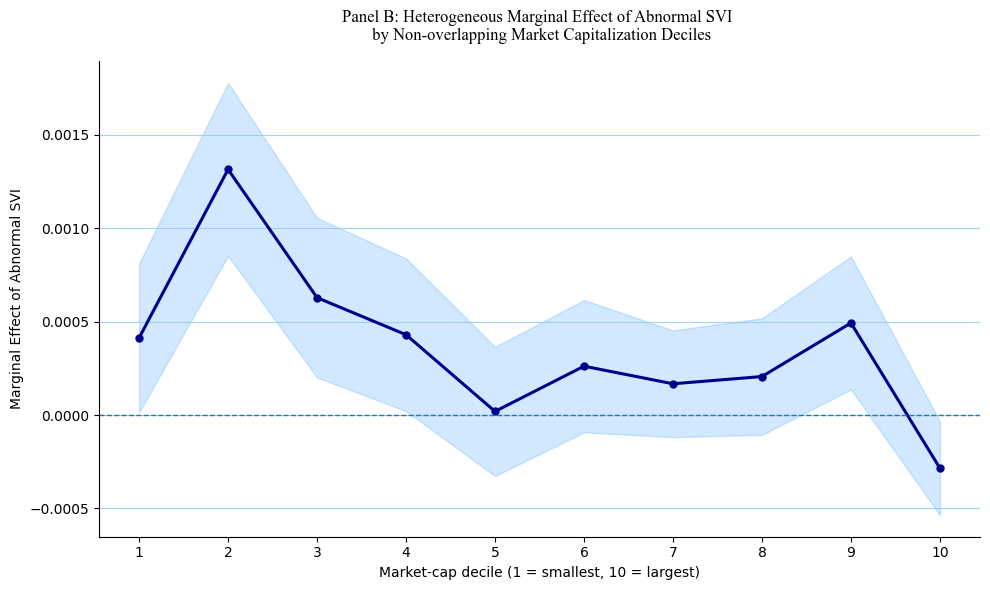

In [39]:
plot_df = me_deciles.copy()

fig, ax = plt.subplots(figsize=(10, 6))

x = plot_df['decile']
y = plot_df['marginal_effect']
y_low = plot_df['ci90_low']
y_high = plot_df['ci90_high']

# 90% confidence interval
ax.fill_between(x, y_low, y_high, alpha=0.20, color="dodgerblue")

# line and markers
ax.plot(x, y, linewidth=2.2, marker='o', markersize=5, color="darkblue")

# zero line
ax.axhline(0, linestyle='--', linewidth=1)

# formatting
ax.set_xlabel('Market-cap decile (1 = smallest, 10 = largest)')
ax.set_ylabel('Marginal Effect of Abnormal SVI')
ax.set_title('Panel B: Heterogeneous Marginal Effect of Abnormal SVI \n by Non-overlapping Market Capitalization Deciles',
             fontsize=12, pad=15, family="Times New Roman")
ax.set_xticks(x)
ax.grid(axis='y', alpha=0.8, color="skyblue")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

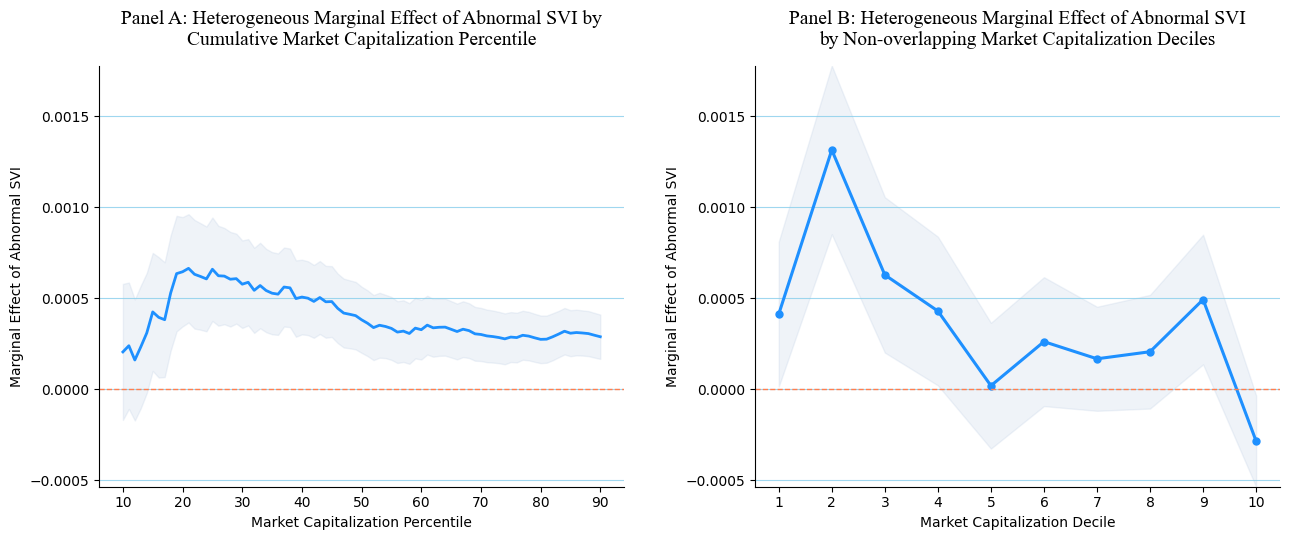

In [62]:
# -----------------------------
# Prepare data
# -----------------------------
plot_df_A = marginal_effects_df.sort_values('percentile').copy()
plot_df_B = me_deciles.copy().sort_values('decile')

# -----------------------------
# Create combined figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=False)

# =========================================================
# Panel A: cumulative market-cap percentile
# =========================================================
ax = axes[0]

ax.fill_between(
    plot_df_A['percentile'],
    plot_df_A['ci90_low'],
    plot_df_A['ci90_high'],
    alpha=0.20,
    color="lightsteelblue"
)

ax.plot(
    plot_df_A['percentile'],
    plot_df_A['marginal_effect'],
    linewidth=2.0,
    color="dodgerblue"
)

ax.axhline(0, linestyle='--', linewidth=1, color='coral')

ax.set_xlabel('Market Capitalization Percentile')
ax.set_ylabel('Marginal Effect of Abnormal SVI')
ax.set_title(
    "Panel A: Heterogeneous Marginal Effect of Abnormal SVI by\n"
    "Cumulative Market Capitalization Percentile",
    fontsize=14,
    pad=15,
    family="Times New Roman"
)
ax.set_xticks(np.arange(10, 91, 10))
ax.grid(axis='y', alpha=0.8, color="skyblue")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# =========================================================
# Panel B: non-overlapping deciles
# =========================================================
ax = axes[1]

x = plot_df_B['decile']
y = plot_df_B['marginal_effect']
y_low = plot_df_B['ci90_low']
y_high = plot_df_B['ci90_high']

ax.fill_between(
    x,
    y_low,
    y_high,
    alpha=0.2,
    color="lightsteelblue"
)

ax.plot(
    x,
    y,
    linewidth=2.2,
    marker='o',
    markersize=5,
    color="dodgerblue"
)

ax.axhline(0, linestyle='--', linewidth=1, color='coral')

ax.set_xlabel('Market Capitalization Decile')
ax.set_ylabel('Marginal Effect of Abnormal SVI')
ax.set_title(
    'Panel B: Heterogeneous Marginal Effect of Abnormal SVI\n'
    'by Non-overlapping Market Capitalization Deciles',
    fontsize=14,
    pad=15,
    family="Times New Roman"
)
ax.set_xticks(x)
ax.grid(axis='y', alpha=0.8, color="skyblue")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -----------------------------
# Final layout and export
# -----------------------------
ymin = min(plot_df_A['ci90_low'].min(), plot_df_B['ci90_low'].min())
ymax = max(plot_df_A['ci90_high'].max(), plot_df_B['ci90_high'].max())

for ax in axes:
    ax.set_ylim(ymin, ymax)
plt.tight_layout(w_pad=3.0)
plt.savefig("../../../figures/marginal_effect_asvi_combined_mktcap.pdf", bbox_inches='tight')
plt.show()

This figure reveals substantial heterogeneity in the predictive effect of abnormal search attention across the market-capitalization distribution. Panel A shows that when small-cap stocks are defined cumulatively, the marginal effect of abnormal SVI on next-day Robinhood herding is positive throughout and is strongest in the lower tail of the size distribution, peaking around the 20th to 25th market-cap percentile before gradually declining as the threshold expands to include larger firms. This pattern suggests that attention-induced herding is concentrated among relatively small stocks and becomes diluted when progressively larger firms are added to the treated group. Panel B confirms this interpretation using non-overlapping market-cap deciles. The effect is largest in the second decile and remains positive for several lower and middle deciles, whereas it is close to zero or negative in the largest-cap segment. Taken together, the two panels indicate that the attention-to-herding channel is not uniform across stocks, but is instead most pronounced among smaller firms, consistent with the view that attention shocks matter more where limits to arbitrage are tighter and retail trading is more likely to move demand.